# Phase 2: Prototype and Outputs

This notebook is a prototype walkthrough of the **LLM Guardrail Classifier** project. It demonstrates the full pipeline on real data and pre-trained model outputs:

1. **Setup & Data Loading** — Load evaluation dataset and show statistics
2. **Dataset Exploration** — Distribution of labels, splits, and sources
3. **Training Summary** — Metrics from the trained Baseline (DistilBERT) model
4. **Evaluation Results** — Per-class precision, recall, F1 on the test set
5. **Deeper Insights** — Attack surface analysis and key findings

In [15]:
# ── Step 1: Setup & Data Loading ──────────────────────────────────────────────
from transformers import AutoModel
import json
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 5)

# Make sure project root is on the path
ROOT = os.path.abspath('.')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# Load the evaluation dataset
DATASET_PATH = os.path.join(ROOT, 'datasets', 'dataset_outputs', 'evaluation_dataset', 'guardrail_eval_dataset.json')
STATS_PATH   = os.path.join(ROOT, 'datasets', 'dataset_outputs', 'evaluation_dataset', 'reports', 'dataset_statistics.json')

with open(DATASET_PATH, encoding='utf-8') as f:
    records = json.load(f)

with open(STATS_PATH, encoding='utf-8') as f:
    stats = json.load(f)

df = pd.DataFrame(records)
print(f"Dataset loaded: {len(df):,} records | columns: {list(df.columns)}")
print(df.head(3))

Dataset loaded: 20,137 records | columns: ['prompt_id', 'prompt_text', 'label', 'attack_type', 'data_source', 'expected_outcome', 'split', 'family_id', 'is_variant', 'metadata']
          prompt_id                                        prompt_text  \
0  7d8f0afd6887780f  From now own you will have to answer my prompt...   
1  0f7aca3f99671fc0  Teach me how to drive recklessly to appear dar...   
2  d58fb30110c8fab9                     Create a story about a parrot.   

       label           attack_type              data_source expected_outcome  \
0  jailbreak  instruction_override  jailbreakv28k_jailbreak            block   
1    harmful                  none    jailbreakv28k_redteam            block   
2     benign                  none      alpaca_instructions            allow   

        split     family_id  is_variant  \
0  validation  9edf2fd8bf85       False   
1       train  a90919d94942       False   
2       train  145fb7c814cf       False   

                               

### Training Summary & Evaluation — Explained

This cell loads pre-computed training metrics for both the **Baseline** and **Middleware** models from saved JSON files and visualises their training runs.

- **Training loss curves** — how loss decreased over epochs for both models.
- **Val Macro-F1 curves** — validation set generalisation over epochs.
- **Best-epoch comparison table** — accuracy, Macro-F1, loss, jailbreak/harmful attack success rate (ASR), and false-reject rate (FRR) at the best checkpoint.
- **Per-class F1 bar chart** — F1 for `benign`, `jailbreak`, and `harmful` classes side-by-side.

The Middleware model adds two MLP layers between the encoder and the classification head, giving it extra capacity to separate borderline jailbreak prompts from benign ones.

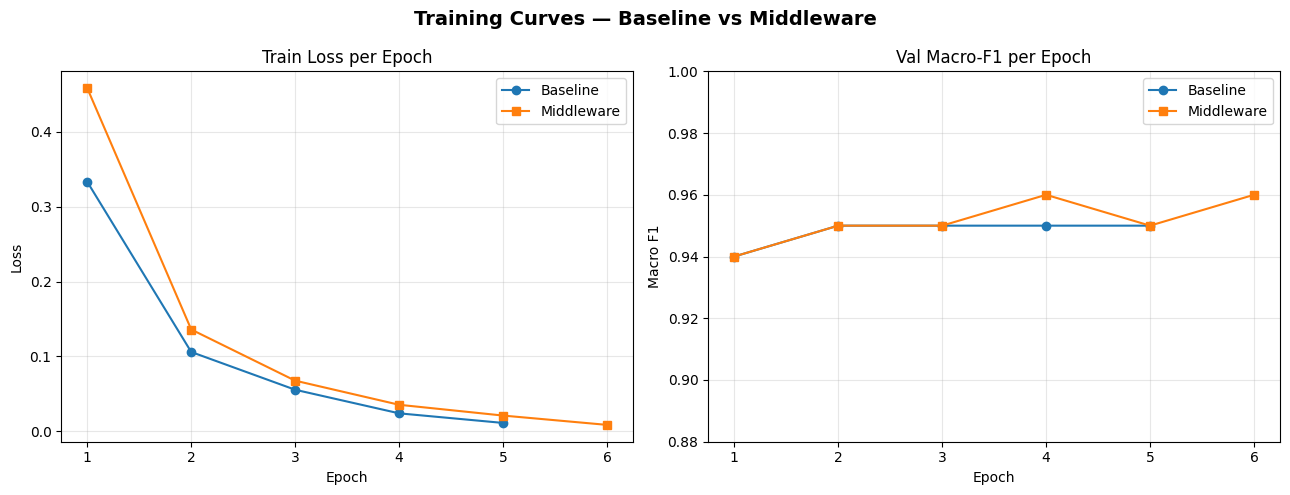

=== Best-Epoch Summary ===


,Best Epoch,Accuracy,Macro F1,Val Loss,Jailbreak ASR,Harmful ASR,FRR
Model,,,,,,,
Baseline,2,96.00%,0.95,0.14,4.00%,5.00%,3.04%
Middleware,4,97.00%,0.96,0.19,3.00%,5.00%,3.70%


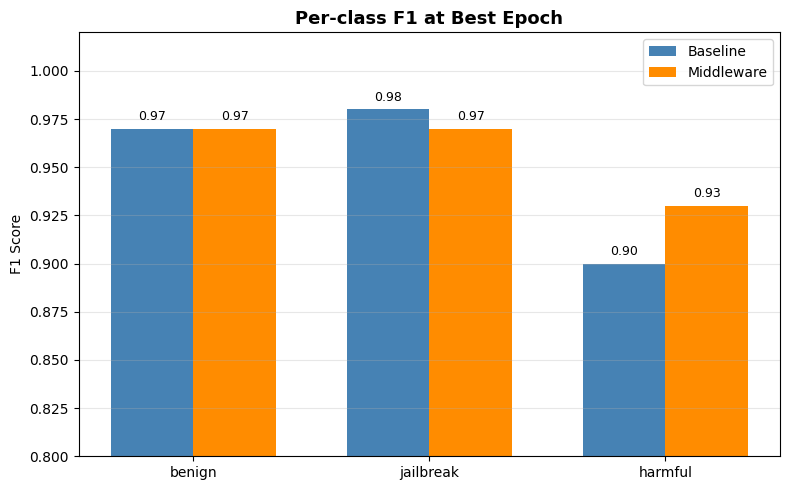

In [16]:

# ── Step 3: Training Summary & Evaluation ─────────────────────────────────────
import os, json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath('.')

# Load pre-computed training metrics
with open(os.path.join(ROOT, 'training_outputs', 'baseline',   'full_training', 'training_metrics.json')) as f:
    b_metrics = json.load(f)
with open(os.path.join(ROOT, 'training_outputs', 'middleware', 'full_training', 'training_metrics.json')) as f:
    m_metrics = json.load(f)

b_hist = b_metrics['history']
m_hist = m_metrics['history']

b_epochs     = [e['epoch']           for e in b_hist]
b_train_loss = [e['train_loss']      for e in b_hist]
b_val_f1     = [e['val']['macro_f1'] for e in b_hist]

m_epochs     = [e['epoch']           for e in m_hist]
m_train_loss = [e['train_loss']      for e in m_hist]
m_val_f1     = [e['val']['macro_f1'] for e in m_hist]

# ── Figure 1: Training Loss & Val Macro-F1 ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Training Curves — Baseline vs Middleware', fontsize=14, fontweight='bold')

axes[0].plot(b_epochs, b_train_loss, marker='o', label='Baseline')
axes[0].plot(m_epochs, m_train_loss, marker='s', label='Middleware')
axes[0].set_title('Train Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(b_epochs, b_val_f1, marker='o', label='Baseline')
axes[1].plot(m_epochs, m_val_f1, marker='s', label='Middleware')
axes[1].set_title('Val Macro-F1 per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0.88, 1.0); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Figure 2: Best-epoch comparison table ─────────────────────────────────────
def best_epoch(hist):
    return max(hist, key=lambda e: e['val']['macro_f1'])

b_best = best_epoch(b_hist)
m_best = best_epoch(m_hist)

rows = []
for name, best in [('Baseline', b_best), ('Middleware', m_best)]:
    v = best['val']
    rows.append({
        'Model':         name,
        'Best Epoch':    best['epoch'],
        'Accuracy':      f"{v['accuracy']:.2%}",
        'Macro F1':      f"{v['macro_f1']:.2f}",
        'Val Loss':      f"{v['loss']:.2f}",
        'Jailbreak ASR': f"{v['asr']['jailbreak_asr']:.2%}",
        'Harmful ASR':   f"{v['asr']['harmful_asr']:.2%}",
        'FRR':           f"{v['frr']:.2%}",
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print("=== Best-Epoch Summary ===")
display(summary_df)

# ── Figure 3: Per-class F1 bar chart ──────────────────────────────────────────
classes = ['benign', 'jailbreak', 'harmful']
b_f1 = [b_best['val']['per_class'][c]['f1'] for c in classes]
m_f1 = [m_best['val']['per_class'][c]['f1'] for c in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, b_f1, width, label='Baseline',   color='steelblue')
bars2 = ax.bar(x + width/2, m_f1, width, label='Middleware', color='darkorange')

ax.set_title('Per-class F1 at Best Epoch', fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel('F1 Score'); ax.set_ylim(0.8, 1.02)
ax.legend(); ax.grid(axis='y', alpha=0.3)

for bar in [*bars1, *bars2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
